<center>
    <img src="https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/Logos/organization_logo/organization_logo.png" width="300" alt="cognitiveclass.ai logo">
</center>


#### Import the required libraries we need for the lab.


In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

#### Read the dataset in the csv file from the URL


In [17]:
boston_df=pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv')

#### Add your code below following the instructions given in the course to complete the peer graded assignment


In [19]:
print(boston_df.head())

   Unnamed: 0     CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  \
0           0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0   
1           1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0   
2           2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0   
3           3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0   
4           4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0   

     TAX  PTRATIO  LSTAT  MEDV  
0  296.0     15.3   4.98  24.0  
1  242.0     17.8   9.14  21.6  
2  242.0     17.8   4.03  34.7  
3  222.0     18.7   2.94  33.4  
4  222.0     18.7   5.33  36.2  


Task 2: Generate Descriptive Statistics and Visualizations

1)For the "Median value of owner-occupied homes" provide a boxplot

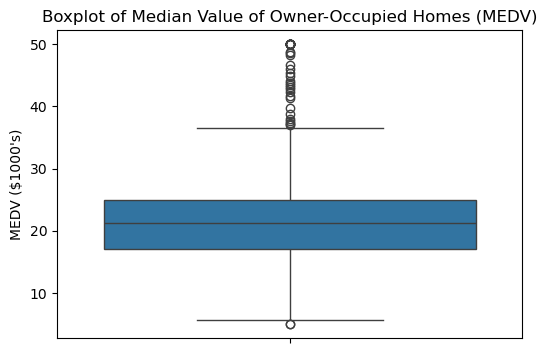

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(y=boston_df['MEDV'])
plt.title("Boxplot of Median Value of Owner-Occupied Homes (MEDV)")
plt.ylabel("MEDV ($1000's)")
plt.show()

2)Provide a  bar plot for the Charles river variable

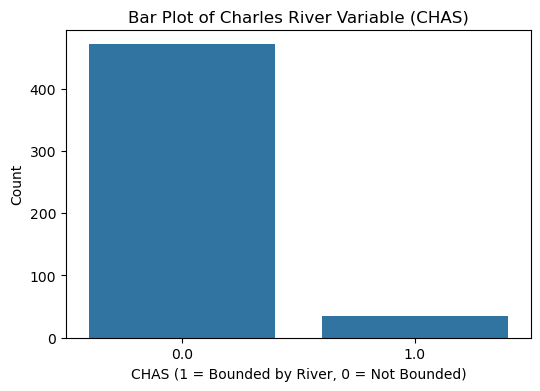

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x='CHAS', data=boston_df)
plt.title("Bar Plot of Charles River Variable (CHAS)")
plt.xlabel("CHAS (1 = Bounded by River, 0 = Not Bounded)")
plt.ylabel("Count")
plt.show()


3) Provide a boxplot for the MEDV variable vs the AGE variable. (Discretize the age variable into three groups of 35 years and younger, between 35 and 70 years and 70 years and older)

In [28]:
bins = [0, 35, 70, 100]
labels = ['≤35', '35–70', '≥70']
boston_df['AGE_Group'] = pd.cut(boston_df['AGE'], bins=bins, labels=labels, include_lowest=True)


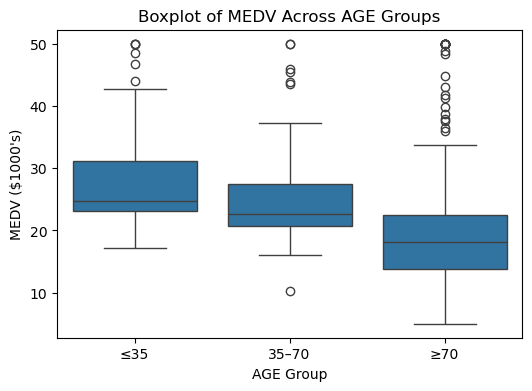

In [30]:
plt.figure(figsize=(6,4))
sns.boxplot(x='AGE_Group', y='MEDV', data=boston_df)
plt.title("Boxplot of MEDV Across AGE Groups")
plt.xlabel("AGE Group")
plt.ylabel("MEDV ($1000's)")
plt.show()


4) Provide a scatter plot to show the relationship between Nitric oxide concentrations and the proportion of non-retail business acres per town. What can you say about the relationship?

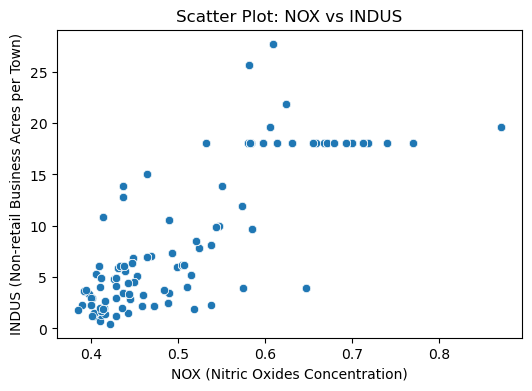

In [35]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='NOX', y='INDUS', data=boston_df)
plt.title("Scatter Plot: NOX vs INDUS")
plt.xlabel("NOX (Nitric Oxides Concentration)")
plt.ylabel("INDUS (Non-retail Business Acres per Town)")
plt.show()


5) Create a histogram for the pupil to teacher ratio variable

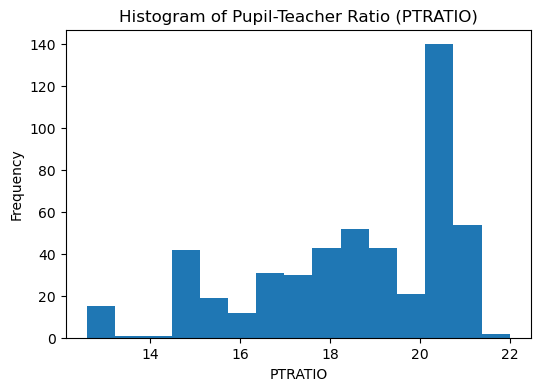

In [38]:
plt.figure(figsize=(6,4))
plt.hist(boston_df['PTRATIO'], bins=15)
plt.title("Histogram of Pupil-Teacher Ratio (PTRATIO)")
plt.xlabel("PTRATIO")
plt.ylabel("Frequency")
plt.show()


Task 3: Use the appropriate tests to answer the questions provided.

1) Is there a significant difference in median value of houses bounded by the Charles river or not? (T-test for independent samples)

In [43]:
from scipy.stats import ttest_ind

chas_1 = boston_df[boston_df['CHAS'] == 1]['MEDV']
chas_0 = boston_df[boston_df['CHAS'] == 0]['MEDV']

t_stat, p_value = ttest_ind(chas_1, chas_0)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Conclusion: Reject H0 → There IS a significant difference.")
else:
    print("Conclusion: Fail to Reject H0 → No significant difference.")


T-statistic: 3.996437466090509
P-value: 7.390623170519905e-05
Conclusion: Reject H0 → There IS a significant difference.


2) Is there a difference in Median values of houses (MEDV) for each proportion of owner occupied units built prior to 1940 (AGE)? (ANOVA)

In [46]:
from scipy.stats import f_oneway

group1 = boston_df[boston_df['AGE_Group']=='≤35']['MEDV']
group2 = boston_df[boston_df['AGE_Group']=='35–70']['MEDV']
group3 = boston_df[boston_df['AGE_Group']=='≥70']['MEDV']

f_stat, p_value = f_oneway(group1, group2, group3)

print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Conclusion: Reject H0 → At least one group mean is different.")
else:
    print("Conclusion: Fail to Reject H0 → No significant difference.")


F-statistic: 36.40764999196599
P-value: 1.7105011022702984e-15
Conclusion: Reject H0 → At least one group mean is different.


3) Can we conclude that there is no relationship between Nitric oxide concentrations and proportion of non-retail business acres per town? (Pearson Correlation)

In [50]:
from scipy.stats import pearsonr

r, p_value = pearsonr(boston_df['NOX'], boston_df['INDUS'])

print("Correlation Coefficient (r):", r)
print("P-value:", p_value)

if p_value < 0.05:
    print("Conclusion: Significant correlation exists.")
else:
    print("Conclusion: No significant correlation.")


Correlation Coefficient (r): 0.7636514469209162
P-value: 7.913361061232958e-98
Conclusion: Significant correlation exists.


4) What is the impact of an additional weighted distance  to the five Boston employment centres on the median value of owner occupied homes? (Regression analysis)

In [53]:
import statsmodels.api as sm

X = boston_df['DIS']
y = boston_df['MEDV']

X = sm.add_constant(X)   # Add intercept
model = sm.OLS(y, X).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Fri, 28 Nov 2025   Prob (F-statistic):           1.21e-08
Time:                        17:39:38   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.0